# **PRAKTIKUM PEMBELAJARAN MESIN**

**Nama**  : Mufliha Hafsyah Shahieza <br>
**NIM**   : 244107020147 <br>
**Kelas** : TI-3G

---

# **JS05 - Klasterisasi Hierarki**<hr>

# **Tugas Praktikum**



## **Langkah 1: Load data dan jalankan HDBSCAN**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import HDBSCAN

iris = load_iris()
X_iris = iris.data
y_true = iris.target

print("Bentuk data:", X_iris.shape)
print("Nama kelas:", iris.target_names)

hdb_iris = HDBSCAN(min_cluster_size=5).fit(X_iris)
labels = hdb_iris.labels_

n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"Jumlah cluster: {n_cluster}")
print(f"Jumlah noise: {n_noise}")

Bentuk data: (150, 4)
Nama kelas: ['setosa' 'versicolor' 'virginica']
Jumlah cluster: 2
Jumlah noise: 0


## **Langkah 2: Visualisasi dengan PCA**

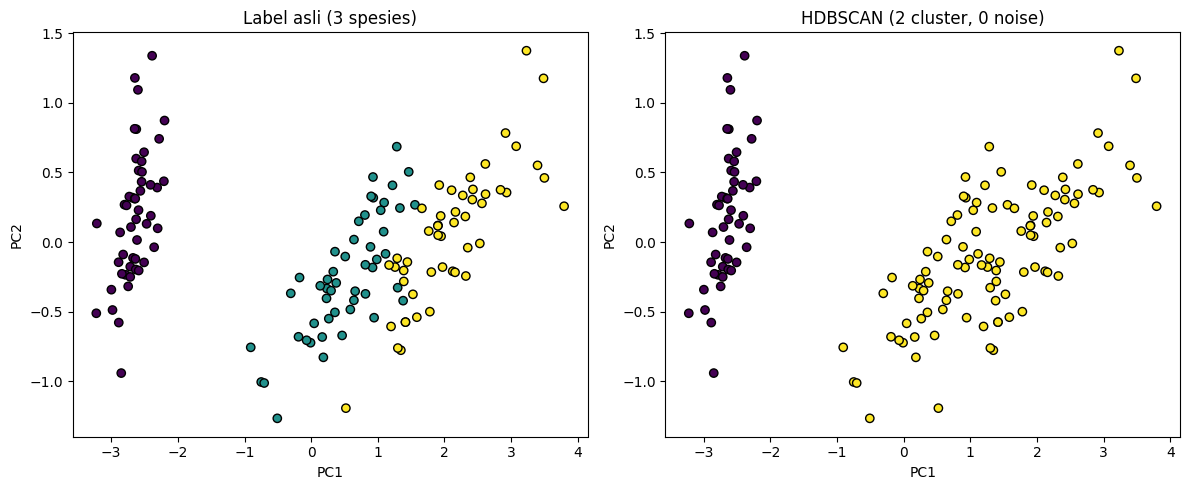

In [5]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="viridis", edgecolor="k")
axes[0].set_title("Label asli (3 spesies)")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", edgecolor="k")
axes[1].set_title(f"HDBSCAN ({n_cluster} cluster, {n_noise} noise)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

## **Langkah 3: Bandingkan dengan label asli**

In [7]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score

tabel = pd.crosstab(
    [iris.target_names[y_true]],
    ["Cluster " + str(l) for l in labels],
)
tabel.index.name = None
tabel.columns.name = None
print(tabel)
print(f"\nAdjusted Rand Index: {adjusted_rand_score(y_true, labels):.3f}")

            Cluster 0  Cluster 1
setosa             50          0
versicolor          0         50
virginica           0         50

Adjusted Rand Index: 0.568


## **Hasil**
* Jumlah cluster: 2
* Noise: 0 titik
* ARI terhadap label asli: 0.568

## **Analisis singkat**
Hasil HDBSCAN hanya sebagian sesuai dengan label asli. HDBSCAN memisahkan setosa dengan sempurna dari dua spesies lainnya, tetapi menggabungkan versicolor dan virginica menjadi satu cluster, sehingga ditemukan 2 cluster, bukan 3. Hal ini terjadi karena HDBSCAN mengelompokkan berdasarkan kepadatan, sedangkan versicolor dan virginica saling tumpang tindih pada ruang fitur (terlihat pada plot PCA), sehingga tidak ada celah kepadatan yang jelas di antara keduanya. Nilai ARI 0.568 menunjukkan kecocokan yang sedang.